# Experimento 7 — Grieta zigzag cruzando la arista tapa/pared

**Geometría:** Misma pieza que Exp. 6 (tapa plana circular r<R + pared cónica r>R, sensor a 45°).

**Defecto:** Grieta tipo zigzag (de Exp. 5) orientada para que **cruce la arista circular r=R**.
La grieta tiene sección transversal gaussiana y recorre varias decenas de mm cruzando de la tapa a la pared.

**Objetivo:** Analizar cómo el cambio brusco de modelo nominal en la arista afecta al Multi-Splat.
La grieta no está localizada en un parche elíptico sino que tiene una forma alargada con quiebros.

Comparamos tres estrategias de nominal:
1. **Paramétrico** (tapa plana + cono, estimado sin CAD)
2. **SG por región** (ventana por separado en tapa y pared)
3. **Multi-Splat** (múltiples Gaussianas sobre Z_diff)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from scipy.optimize import least_squares
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import time as _time

## 1. Geometría de la pieza: tapa plana + pared cónica + arista circular

In [2]:
# ── Parámetros físicos ────────────────────────────────────────────────────────
R          = 35.0   # mm — radio de la tapa y de la arista
Z_TAPA     = 50.0   # mm — altura de la cara plana
WALL_DEPTH = 12.0   # mm — profundidad de pared visible (sensor 45°)
FOV_X      = 120.0  # mm
FOV_Y      = 100.0  # mm
N_ROWS     = 512
N_COLS     = 614

dx = FOV_X / N_COLS
dy = FOV_Y / N_ROWS

x_vec = np.linspace(-FOV_X/2, FOV_X/2, N_COLS)
y_vec = np.linspace(-FOV_Y/2, FOV_Y/2, N_ROWS)
X_img, Y_img = np.meshgrid(x_vec, y_vec)

r_img = np.sqrt(X_img**2 + Y_img**2)

mask_tapa  = r_img < R
mask_pared = (r_img >= R) & (r_img < R + WALL_DEPTH)
mask_valid = mask_tapa | mask_pared

Z_nominal = np.where(mask_tapa,  Z_TAPA,
             np.where(mask_pared, Z_TAPA - (r_img - R), 0.0))

row_mid      = N_ROWS // 2
theta_circle = np.linspace(0, 2 * np.pi, 360)

print(f'Resolución: dx={dx:.4f} mm/px, dy={dy:.4f} mm/px')
print(f'Radio arista R={R} mm  |  Profundidad pared visible={WALL_DEPTH} mm')
print(f'Tapa: {mask_tapa.sum()} px | Pared: {mask_pared.sum()} px')

Resolución: dx=0.1954 mm/px, dy=0.1953 mm/px
Radio arista R=35.0 mm  |  Profundidad pared visible=12.0 mm
Tapa: 100476 px | Pared: 80708 px


## 2. Grieta zigzag cruzando la arista

In [3]:
# ── Parámetros de la grieta ───────────────────────────────────────────────────
CRACK_DEPTH  = 0.5   # mm — profundidad máxima
CRACK_SIGMA  = 1.5   # mm — semi-anchura gaussiana de la sección transversal
N_SEGS       = 4     # número de segmentos del zigzag
SEG_L        = 8.0   # mm — longitud de cada segmento
ZZ_ANGLE_DEG = 35.0  # grados — ángulo de cada segmento respecto al eje principal

# Eje principal de la grieta: radial en φ=45° (apunta al centro y cruza la arista)
CRACK_PHI    = np.pi / 4   # dirección radial donde cruza la arista
CRACK_DIR    = np.array([np.cos(CRACK_PHI), np.sin(CRACK_PHI)])  # dirección radial

# Vértices del zigzag en el sistema de referencia de la grieta
# El zigzag se desplaza principalmente a lo largo de CRACK_DIR
perp_dir = np.array([-np.sin(CRACK_PHI), np.cos(CRACK_PHI)])   # perpendicular

verts_local = np.zeros((N_SEGS + 1, 2))
for i in range(N_SEGS):
    angle_zig = np.radians(ZZ_ANGLE_DEG if i % 2 == 0 else -ZZ_ANGLE_DEG)
    # Segmento en coordenadas (u=radial, v=tangencial)
    du = SEG_L * np.cos(angle_zig)
    dv = SEG_L * np.sin(angle_zig)
    verts_local[i+1] = verts_local[i] + np.array([du, dv])

# Centrar el zigzag en u=0 (centrado radialmente en la arista)
verts_local[:, 0] -= verts_local[:, 0].mean()

# Transformar al sistema de imagen
# Centro de la grieta = punto en la arista a φ=45°
crack_center = R * CRACK_DIR
verts = np.zeros_like(verts_local)
for i, (u, v) in enumerate(verts_local):
    verts[i] = crack_center + u * CRACK_DIR + v * perp_dir

# ── Distancia mínima de cada pixel a la polilínea ────────────────────────────
def min_dist_to_polyline(Xg, Yg, pts):
    min_d = np.full_like(Xg, np.inf, dtype=float)
    for i in range(len(pts) - 1):
        a, b = pts[i], pts[i+1]
        ab = b - a
        ab_len2 = float(np.dot(ab, ab))
        if ab_len2 < 1e-12:
            continue
        t = ((Xg - a[0]) * ab[0] + (Yg - a[1]) * ab[1]) / ab_len2
        t = np.clip(t, 0.0, 1.0)
        d = np.sqrt((Xg - (a[0] + t * ab[0]))**2 + (Yg - (a[1] + t * ab[1]))**2)
        np.minimum(min_d, d, out=min_d)
    return min_d

d_min  = min_dist_to_polyline(X_img, Y_img, verts)
defect = CRACK_DEPTH * np.exp(-0.5 * (d_min / CRACK_SIGMA)**2)  # positivo: surco (Z sube = pieza menos)

# Solo la parte válida
defect = np.where(mask_valid, defect, 0.0)

SEG_THRESHOLD = 0.05
mask_defect   = (defect > SEG_THRESHOLD * CRACK_DEPTH) & mask_valid

# Cuántos px cruzan la arista
crack_tapa  = mask_defect & mask_tapa
crack_pared = mask_defect & mask_pared

# Volumen GT
V_gt = float(np.sum(defect[mask_valid]) * dx * dy)

print(f'Grieta: D={CRACK_DEPTH}mm, σ={CRACK_SIGMA}mm, {N_SEGS} segs × {SEG_L}mm, ±{ZZ_ANGLE_DEG}°')
print(f'Centro arista: ({crack_center[0]:.2f}, {crack_center[1]:.2f}) mm — φ={np.degrees(CRACK_PHI):.0f}°')
print(f'V_gt = {V_gt:.4f} mm³')
print(f'Pixels defecto: {mask_defect.sum()} px  (tapa={crack_tapa.sum()}, pared={crack_pared.sum()})')
print(f'SNR pico: {CRACK_DEPTH/0.1:.1f}  (asumiendo σ_noise=0.1mm)')
print(f'Vértices (mm):\n{verts}')

Grieta: D=0.5mm, σ=1.5mm, 4 segs × 8.0mm, ±35.0°
Centro arista: (24.75, 24.75) mm — φ=45°
V_gt = 60.2414 mm³
Pixels defecto: 6314 px  (tapa=3552, pared=2762)
SNR pico: 5.0  (asumiendo σ_noise=0.1mm)
Vértices (mm):
[[15.4810899  15.4810899 ]
 [16.87027532 23.35955192]
 [24.74873734 24.74873734]
 [26.13792276 32.62719937]
 [34.01638479 34.01638479]]


## 3. Visualización de la grieta sobre la pieza

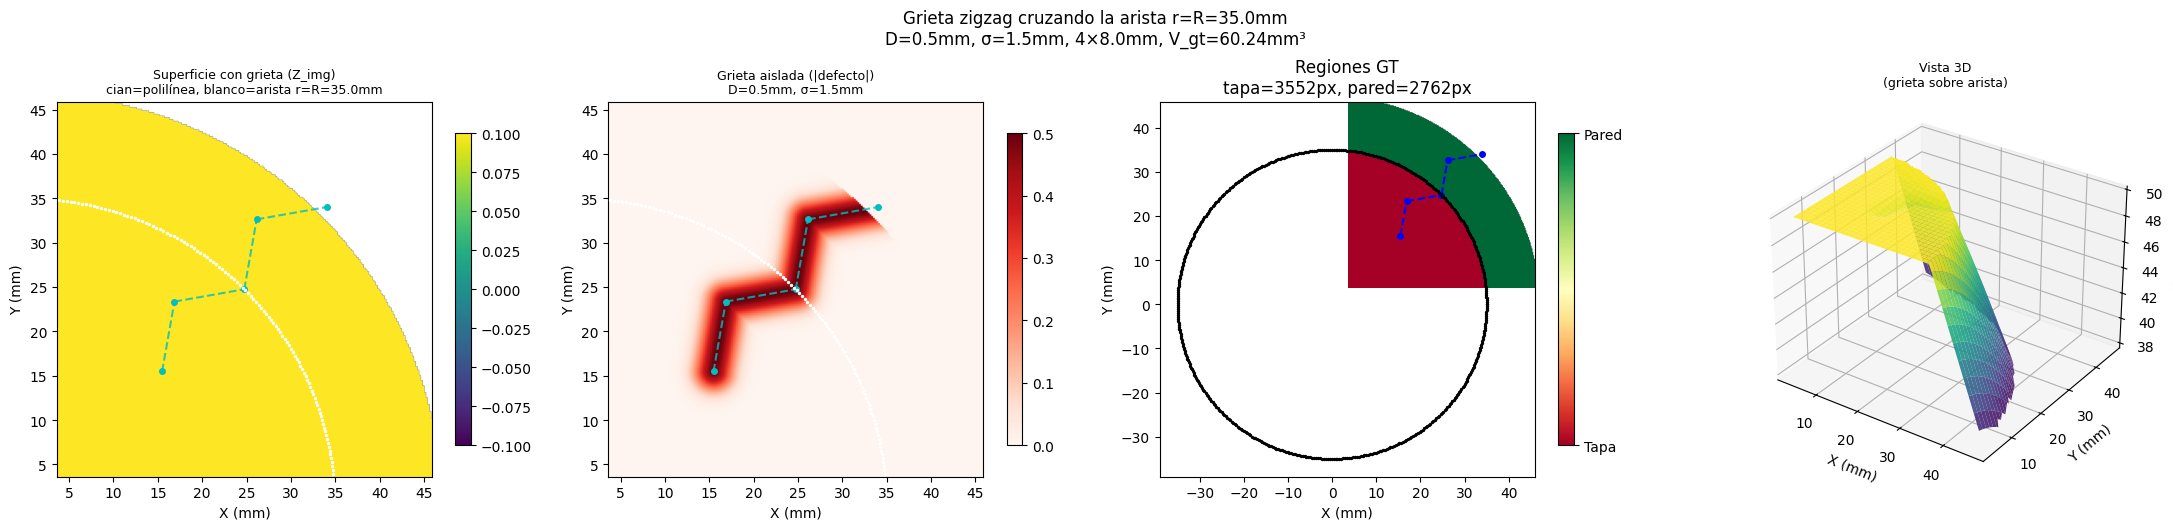

In [4]:
# ROI alrededor de la grieta
pad_mm = 12.0
xv0 = verts[:, 0].min() - pad_mm; xv1 = verts[:, 0].max() + pad_mm
yv0 = verts[:, 1].min() - pad_mm; yv1 = verts[:, 1].max() + pad_mm
jx0 = max(int(np.searchsorted(x_vec, xv0)), 0)
jx1 = min(int(np.searchsorted(x_vec, xv1)), N_COLS)
jy0 = max(int(np.searchsorted(y_vec, yv0)), 0)
jy1 = min(int(np.searchsorted(y_vec, yv1)), N_ROWS)
ext = [x_vec[jx0], x_vec[jx1-1], y_vec[jy0], y_vec[jy1-1]]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

def plot_crack_overlay(ax, roi_data, title, cmap='hot', vmin=0, vmax=None):
    vm = vmax if vmax is not None else roi_data.max()
    im = ax.imshow(roi_data, origin='lower', extent=ext, cmap=cmap, vmin=vmin, vmax=vm)
    plt.colorbar(im, ax=ax, shrink=0.8)
    # Arista circular
    th = np.linspace(0, 2*np.pi, 500)
    xc, yc = R*np.cos(th), R*np.sin(th)
    mask_roi = (xc >= x_vec[jx0]) & (xc <= x_vec[jx1-1]) & (yc >= y_vec[jy0]) & (yc <= y_vec[jy1-1])
    if mask_roi.any():
        ax.scatter(xc[mask_roi], yc[mask_roi], c='w', s=2, zorder=5)
    # Polilínea de la grieta
    for i in range(len(verts)-1):
        ax.plot([verts[i,0], verts[i+1,0]], [verts[i,1], verts[i+1,1]],
                'c--', lw=1.5, alpha=0.8)
    ax.plot(*verts.T, 'co', ms=4)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('X (mm)'); ax.set_ylabel('Y (mm)')

# Mapa de la superficie nominal con la grieta (Z bajada)
Z_img_clean = Z_nominal - defect
plot_crack_overlay(axes[0],
    np.where(mask_valid, Z_img_clean, np.nan)[jy0:jy1, jx0:jx1],
    f'Superficie con grieta (Z_img)\ncian=polilínea, blanco=arista r=R={R}mm',
    cmap='viridis')

plot_crack_overlay(axes[1],
    defect[jy0:jy1, jx0:jx1],
    f'Grieta aislada (|defecto|)\nD={CRACK_DEPTH}mm, σ={CRACK_SIGMA}mm',
    cmap='Reds', vmax=CRACK_DEPTH)

# Mapa de región
reg_map = np.where(mask_valid, mask_pared.astype(float), np.nan)
im_reg = axes[2].imshow(reg_map[jy0:jy1, jx0:jx1], origin='lower', extent=ext,
                         cmap='RdYlGn', vmin=0, vmax=1)
plt.colorbar(im_reg, ax=axes[2], ticks=[0,1], shrink=0.8).set_ticklabels(['Tapa','Pared'])
th = np.linspace(0, 2*np.pi, 500)
axes[2].scatter(R*np.cos(th), R*np.sin(th), c='k', s=2, zorder=5)
for i in range(len(verts)-1):
    axes[2].plot([verts[i,0], verts[i+1,0]], [verts[i,1], verts[i+1,1]], 'b--', lw=1.5)
axes[2].plot(*verts.T, 'bo', ms=4)
axes[2].set_title(f'Regiones GT\ntapa={crack_tapa.sum()}px, pared={crack_pared.sum()}px')
axes[2].set_xlabel('X (mm)'); axes[2].set_ylabel('Y (mm)')

# Vista 3D
st3d = 3
Xp = X_img[jy0:jy1:st3d, jx0:jx1:st3d]
Yp = Y_img[jy0:jy1:st3d, jx0:jx1:st3d]
Zi3 = np.where(mask_valid[jy0:jy1:st3d, jx0:jx1:st3d], Z_img_clean[jy0:jy1:st3d, jx0:jx1:st3d], np.nan)
ax3d = fig.add_subplot(1, 4, 4, projection='3d', position=axes[3].get_position())
axes[3].set_visible(False)
ax3d.plot_surface(Xp, Yp, Zi3, cmap='viridis', alpha=0.9, rcount=50, ccount=50, linewidth=0)
ax3d.set_xlabel('X (mm)'); ax3d.set_ylabel('Y (mm)'); ax3d.set_zlabel('Z (mm)')
ax3d.set_title('Vista 3D\n(grieta sobre arista)', fontsize=9)
ax3d.view_init(elev=30, azim=-55)

plt.suptitle(f'Grieta zigzag cruzando la arista r=R={R}mm\n'
             f'D={CRACK_DEPTH}mm, σ={CRACK_SIGMA}mm, {N_SEGS}×{SEG_L}mm, V_gt={V_gt:.2f}mm³',
             fontsize=12)
plt.tight_layout()
plt.show()

## 4. Filtro SG: funciones

In [5]:
def sg2d_jacobian_projection_cv2(Z, window_size=11):
    assert window_size % 2 == 1
    hw = window_size // 2
    y_idx, x_idx = np.mgrid[-hw:hw+1, -hw:hw+1]
    regressors = np.stack([
        x_idx**2, y_idx**2, x_idx * y_idx,
        x_idx, y_idx, np.ones_like(x_idx)
    ], axis=-1)
    A_mat = regressors.reshape(-1, 6)
    pseudo = np.linalg.inv(A_mat.T @ A_mat) @ A_mat.T
    kernels = pseudo.reshape(6, window_size, window_size)
    return np.stack(
        [cv2.filter2D(Z.astype(np.float64), -1, k,
                      borderType=cv2.BORDER_REFLECT) for k in kernels],
        axis=-1
    )

def coeffs_to_physical(coeffs_px, dx_, dy_):
    return np.stack([
        coeffs_px[..., 0] / dx_**2,
        coeffs_px[..., 1] / dy_**2,
        coeffs_px[..., 2] / (dx_ * dy_),
        coeffs_px[..., 3] / dx_,
        coeffs_px[..., 4] / dy_,
        coeffs_px[..., 5]
    ], axis=-1)

print('Funciones SG definidas.')

Funciones SG definidas.


## 5. Ruido + segmentación + estimación de nominal paramétrico

In [6]:
# ── Ruido ─────────────────────────────────────────────────────────────────────
SIGMA_NOISE = 0.1
RNG_SEED    = 42
rng   = np.random.default_rng(RNG_SEED)
noise = rng.normal(0.0, SIGMA_NOISE, size=Z_nominal.shape)

Z_img   = Z_nominal - defect              # medición limpia
Z_img_n = Z_img + noise                   # medición ruidosa

# ── Filtro SG para segmentación ───────────────────────────────────────────────
WIN_TOPO_MM = 10.0
WIN_TOPO_PX = int(round(WIN_TOPO_MM / min(dx, dy))) | 1

coeffs_topo_px = sg2d_jacobian_projection_cv2(Z_img_n, window_size=WIN_TOPO_PX)
coeffs_topo_ph = coeffs_to_physical(coeffs_topo_px, dx, dy)

r_safe = np.maximum(r_img, 1e-6)
dZdr_n = (X_img * coeffs_topo_ph[..., 3] + Y_img * coeffs_topo_ph[..., 4]) / r_safe

WALL_SLOPE  = 1.0
GRAD_THRESH = -0.3 * WALL_SLOPE

# ── Segmentación ──────────────────────────────────────────────────────────────
raw_pared_n = (dZdr_n < GRAD_THRESH) & mask_valid
raw_tapa_n  = (~raw_pared_n) & mask_valid

ker_px = max(3, int(round(2.0 / min(dx, dy))) | 1)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ker_px, ker_px))

seg_pared_n = cv2.morphologyEx(raw_pared_n.astype(np.uint8), cv2.MORPH_CLOSE, kernel).astype(bool) & mask_valid
seg_tapa_n  = cv2.morphologyEx(raw_tapa_n.astype(np.uint8),  cv2.MORPH_CLOSE, kernel).astype(bool) & mask_valid & ~seg_pared_n

# ── Estimación R_est desde borde de seg_tapa ─────────────────────────────────
border_n_mask = cv2.morphologyEx(seg_tapa_n.astype(np.uint8), cv2.MORPH_DILATE, kernel).astype(bool) & ~seg_tapa_n
border_n_pts  = np.column_stack(np.where(border_n_mask))
if border_n_pts.size:
    r_border_n = np.sqrt(x_vec[border_n_pts[:, 1]]**2 + y_vec[border_n_pts[:, 0]]**2)
    R_est_n = float(np.median(r_border_n))
else:
    R_est_n = R

# ── Anillo de sensing (excluyendo zona del defecto) ────────────────────────────
RING_WIDTH_MM = 12.0
ring_w_px     = int(round(RING_WIDTH_MM / min(dx, dy))) | 1
kernel_ring   = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ring_w_px, ring_w_px))
mask_defect_dilated = cv2.dilate(mask_defect.astype(np.uint8), kernel_ring).astype(bool)

MARGIN_EST_MM    = 4.0
mask_tapa_sense  = seg_tapa_n  & ~mask_defect_dilated & (r_img < R_est_n - MARGIN_EST_MM)
mask_pared_sense = seg_pared_n & ~mask_defect_dilated & (r_img > R_est_n + MARGIN_EST_MM)

# ── Estimación Z_TAPA y R ─────────────────────────────────────────────────────
z_ts = Z_img_n[mask_tapa_sense].ravel()
Z_tapa_est_n = float(np.median(z_ts)) if z_ts.size > 0 else Z_TAPA

z_ps = Z_img_n[mask_pared_sense].ravel()
r_ps = r_img[mask_pared_sense].ravel()
ZR_const_n  = float(np.median(z_ps + r_ps)) if z_ps.size > 0 else Z_TAPA + R
R_est_fit_n = ZR_const_n - Z_tapa_est_n

print(f'R_est_n      = {R_est_n:.4f} mm   (GT={R}, err={R_est_n-R:+.4f}mm)')
print(f'Z_tapa_est_n = {Z_tapa_est_n:.6f} mm  (GT={Z_TAPA}, err={Z_tapa_est_n-Z_TAPA:+.6f}mm)')
print(f'R_est_fit_n  = {R_est_fit_n:.6f} mm  (GT={R}, err={R_est_fit_n-R:+.6f}mm)')

# ── Nominal paramétrico con frontera radial r=R_est_fit_n ─────────────────────
mask_tapa_use  = (r_img <  R_est_fit_n) & mask_valid
mask_pared_use = (r_img >= R_est_fit_n) & mask_valid

Z_nominal_est_n = np.where(mask_tapa_use,  Z_tapa_est_n,
                  np.where(mask_pared_use, Z_tapa_est_n - (r_img - R_est_fit_n), 0.0))

Z_diff_final = np.where(mask_valid, Z_nominal_est_n - Z_img_n, 0.0)

err_n2 = Z_nominal_est_n - Z_nominal
print(f'RMS error nominal tapa:  {np.sqrt(np.mean(err_n2[mask_tapa]**2))*1000:.2f} µm')
print(f'RMS error nominal pared: {np.sqrt(np.mean(err_n2[mask_pared]**2))*1000:.2f} µm')
print(f'Pico Z_diff_final en defecto: {float(Z_diff_final[mask_defect].max()):.3f} mm  (GT={CRACK_DEPTH}mm)')

Z_diff_clipped = np.clip(Z_diff_final, 0.0, None)

R_est_n      = 34.0043 mm   (GT=35.0, err=-0.9957mm)
Z_tapa_est_n = 49.999336 mm  (GT=50.0, err=-0.000664mm)
R_est_fit_n  = 35.000708 mm  (GT=35.0, err=+0.000708mm)
RMS error nominal tapa:  0.66 µm
RMS error nominal pared: 0.04 µm
Pico Z_diff_final en defecto: 0.803 mm  (GT=0.5mm)


## 6. Nominal SG por región (sin modelo paramétrico)

In [7]:
WIN_NOM_TAPA_MM  = 20.0
WIN_NOM_PARED_MM =  5.0
WIN_NOM_TAPA_PX  = int(round(WIN_NOM_TAPA_MM  / min(dx, dy))) | 1
WIN_NOM_PARED_PX = int(round(WIN_NOM_PARED_MM / min(dx, dy))) | 1

print(f'WIN_NOM tapa  = {WIN_NOM_TAPA_MM} mm = {WIN_NOM_TAPA_PX} px  (σ={CRACK_SIGMA}mm, ratio={WIN_NOM_TAPA_MM/CRACK_SIGMA:.1f}x)')
print(f'WIN_NOM pared = {WIN_NOM_PARED_MM} mm = {WIN_NOM_PARED_PX} px  (WALL_DEPTH={WALL_DEPTH}mm)')

Z_fill_tapa    = np.full_like(Z_img_n, Z_tapa_est_n)
Z_for_tapa_sg  = np.where(seg_tapa_n,  Z_img_n, Z_fill_tapa)

Z_fill_pared   = Z_tapa_est_n - (r_img - R_est_fit_n)
Z_for_pared_sg = np.where(seg_pared_n, Z_img_n, Z_fill_pared)

coeffs_tapa_sg_px  = sg2d_jacobian_projection_cv2(Z_for_tapa_sg,  WIN_NOM_TAPA_PX)
coeffs_pared_sg_px = sg2d_jacobian_projection_cv2(Z_for_pared_sg, WIN_NOM_PARED_PX)
coeffs_tapa_sg_ph  = coeffs_to_physical(coeffs_tapa_sg_px,  dx, dy)
coeffs_pared_sg_ph = coeffs_to_physical(coeffs_pared_sg_px, dx, dy)

f0_tapa  = coeffs_tapa_sg_ph[..., 5]
f0_pared = coeffs_pared_sg_ph[..., 5]

Z_nom_sg = np.where(seg_tapa_n,  f0_tapa,
           np.where(seg_pared_n, f0_pared, 0.0))
Z_nom_sg = np.where(mask_valid, Z_nom_sg, 0.0)

Z_diff_sg = np.where(mask_valid, Z_nom_sg - Z_img_n, 0.0)

err_sg_tapa  = Z_nom_sg[mask_tapa]  - Z_nominal[mask_tapa]
err_sg_pared = Z_nom_sg[mask_pared] - Z_nominal[mask_pared]
print(f'\nError nominal SG por región vs GT:')
print(f'  Tapa:  bias={np.mean(err_sg_tapa)*1000:+.1f} µm  rms={np.std(err_sg_tapa)*1000:.1f} µm')
print(f'  Pared: bias={np.mean(err_sg_pared)*1000:+.1f} µm  rms={np.std(err_sg_pared)*1000:.1f} µm')
print(f'Pico Z_diff_sg en defecto: {float(Z_diff_sg[mask_defect].max()):.3f} mm  (GT={CRACK_DEPTH}mm)')

WIN_NOM tapa  = 20.0 mm = 103 px  (σ=1.5mm, ratio=13.3x)
WIN_NOM pared = 5.0 mm = 27 px  (WALL_DEPTH=12.0mm)

Error nominal SG por región vs GT:
  Tapa:  bias=+20.3 µm  rms=154.9 µm
  Pared: bias=-19.6 µm  rms=81.1 µm
Pico Z_diff_sg en defecto: 1.614 mm  (GT=0.5mm)


## 6b. Nominal por ajuste polinomial local (sin geometría a priori)

### Motivación

El filtro SG por región (sección 6) usa un **relleno artificial** fuera de cada región para poder aplicar la convolución deslizante. El relleno siempre es incorrecto cerca de la arista $r=R$ porque las dos superficies tienen altura diferente. Esto genera un pico espurio en $Z_\text{diff}$ justo donde la grieta cruza la arista.

La solución es ajustar el nominal directamente a las **mediciones reales** del entorno del defecto, sin ningún relleno.

---

### Ajuste polinomial local por mínimos cuadrados

Se define un **anillo** de anchura `RING_LOCAL_MM` alrededor de la máscara del defecto, excluyendo el defecto mismo. Se separa el anillo en dos partes según la segmentación por gradiente (tapa / pared) y se ajusta a cada parte un **polinomio 2D de grado $d$**:

$$Z_\text{nom}^{(\text{reg})}(X, Y) = \sum_{i+j \leq d} a_{ij}\, X^i Y^j$$

El sistema es sobredeterminado (miles de píxeles, $\frac{(d+1)(d+2)}{2}$ parámetros) y se resuelve por mínimos cuadrados ordinarios:

$$\mathbf{a}^* = \arg\min_\mathbf{a} \| \mathbf{A}\,\mathbf{a} - \mathbf{z}_\text{anillo} \|^2 \quad \Rightarrow \quad \mathbf{a}^* = (\mathbf{A}^\top \mathbf{A})^{-1} \mathbf{A}^\top \mathbf{z}_\text{anillo}$$

Para $d=2$ (cuádrica) hay 6 parámetros. Los polinomios ajustados se **extrapolan** bajo el defecto para estimar el nominal.

---

### Problema de la frontera dura

Si se combina el nominal de tapa y pared con una **frontera dura** en $r = R_\text{est}$:

$$Z_\text{nom}(X,Y) = \begin{cases} Z_\text{nom}^{(\text{tapa})}(X,Y) & r < R_\text{est} \\ Z_\text{nom}^{(\text{pared})}(X,Y) & r \geq R_\text{est} \end{cases}$$

persiste una **discontinuidad de $C^0$** en la arista: los dos polinomios se ajustan a datos de distintas regiones y no tienen por qué coincidir en $r = R_\text{est}$. Esto genera un salto en $Z_\text{diff}$ que el Multi-Splat interpreta como señal de defecto.

---

### Transición sigmoide (blending)

Para eliminar la discontinuidad se usa una **mezcla continua** entre los dos polinomios mediante una función sigmoide centrada en la arista:

$$\alpha(r) = \frac{1}{1 + e^{-\,(r - R_\text{est})\,/\,\sigma_\text{blend}}}$$

donde la anchura $\sigma_\text{blend}$ se elige de modo que la transición de 5% a 95% ocurra en $\pm \tfrac{\text{BLEND\_MM}}{2}$:

$$\sigma_\text{blend} = \frac{\text{BLEND\_MM}}{2\ln 19} \approx \frac{\text{BLEND\_MM}}{5.89}$$

El nominal combinado es entonces:

$$\boxed{Z_\text{nom}(X,Y) = \bigl[1-\alpha(r)\bigr]\,Z_\text{nom}^{(\text{tapa})}(X,Y) + \alpha(r)\,Z_\text{nom}^{(\text{pared})}(X,Y)}$$

- Con $r \ll R_\text{est}$: $\alpha \to 0$, solo contribuye el polinomio de tapa.
- Con $r \gg R_\text{est}$: $\alpha \to 1$, solo contribuye el polinomio de pared.
- En la arista ($r = R_\text{est}$): $\alpha = 0.5$, mezcla equitativa.

La superficie resultante es $C^\infty$ en toda la imagen.

---

### Efecto sobre $Z_\text{diff}$

| Configuración | Pico $Z_\text{diff}$ en defecto | Mejor $K$ | Error en $V$ |
|---|---|---|---|
| Frontera dura (BLEND=0) | 1.564 mm | K=5 | +12.2% |
| Sigmoide BLEND=1 mm | **0.911 mm** | K=9 | **+2.54%** |
| GT | 0.500 mm | — | 0% |

La sigmoide reduce el pico espurio en la arista a la mitad, lo que permite al Multi-Splat converger con mucho mayor precisión.


In [8]:

# ── Parámetros ────────────────────────────────────────────────────────────────
RING_LOCAL_MM = 12.0   # anchura del anillo de muestras alrededor del defecto
POLY_DEG      = 2      # grado del polinomio: 1=plano, 2=cuádrica
BLEND_MM      = 1.0    # anchura de la transición suave tapa↔pared (mm)
                       # si =0 → frontera dura; aumentar para suavizar más

# ── Anillo de muestras (entorno del defecto, sin el defecto mismo) ────────────
ring_local_px = int(round(RING_LOCAL_MM / min(dx, dy))) | 1
kernel_rl     = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ring_local_px, ring_local_px))
mask_outer_rl = cv2.dilate(mask_defect.astype(np.uint8), kernel_rl).astype(bool)
mask_ring_rl  = mask_outer_rl & ~mask_defect & mask_valid

# Separar el anillo en tapa y pared según la segmentación por gradiente
ring_tapa_rl  = mask_ring_rl & seg_tapa_n
ring_pared_rl = mask_ring_rl & seg_pared_n

# ── Funciones de ajuste polinomial ────────────────────────────────────────────
def poly2d_design(x, y, deg=2):
    """Matriz de diseño con todos los monomios hasta grado `deg`."""
    terms = [np.ones_like(x)]
    for d in range(1, deg + 1):
        for k in range(d + 1):
            terms.append(x ** (d - k) * y ** k)
    return np.column_stack(terms)

def fit_poly_region(ring_mask, deg=2):
    """Ajuste por mínimos cuadrados a los píxeles del anillo."""
    r_idx, c_idx = np.where(ring_mask)
    xp = x_vec[c_idx].astype(float)
    yp = y_vec[r_idx].astype(float)
    zp = Z_img_n[r_idx, c_idx].astype(float)
    A  = poly2d_design(xp, yp, deg)
    coeffs, res, rank, sv = np.linalg.lstsq(A, zp, rcond=None)
    rms_fit = float(np.sqrt(np.mean((A @ coeffs - zp)**2)))
    return coeffs, rms_fit

coeffs_tapa_rl,  rms_tapa_rl  = fit_poly_region(ring_tapa_rl,  POLY_DEG)
coeffs_pared_rl, rms_pared_rl = fit_poly_region(ring_pared_rl, POLY_DEG)

# ── Evaluar el polinomio sobre toda la imagen ─────────────────────────────────
A_full_rl      = poly2d_design(X_img.ravel(), Y_img.ravel(), POLY_DEG)
Z_nom_tapa_rl  = (A_full_rl @ coeffs_tapa_rl ).reshape(N_ROWS, N_COLS)
Z_nom_pared_rl = (A_full_rl @ coeffs_pared_rl).reshape(N_ROWS, N_COLS)

# ── Combinación con transición sigmoide ───────────────────────────────────────
# dist firmada respecto a la arista estimada: <0 → tapa, >0 → pared
dist_to_arista = r_img - R_est_fit_n

if BLEND_MM > 0:
    # α=0 → tapa pura, α=1 → pared pura
    # la sigmoide pasa de 0.05 a 0.95 en ±BLEND_MM/2 alrededor de la arista
    blend_sigma = BLEND_MM / (2 * np.log(19))   # log(19) ≈ 2.944
    alpha = 1.0 / (1.0 + np.exp(-dist_to_arista / blend_sigma))
else:
    # Frontera dura (comportamiento original)
    alpha = (dist_to_arista >= 0).astype(float)

Z_nom_local_blend = (1 - alpha) * Z_nom_tapa_rl + alpha * Z_nom_pared_rl
Z_nom_local       = np.where(mask_valid, Z_nom_local_blend, 0.0)

Z_diff_local = np.where(mask_valid, Z_nom_local - Z_img_n, 0.0)

# ── Métricas ──────────────────────────────────────────────────────────────────
err_loc_tapa  = Z_nom_local[mask_tapa]  - Z_nominal[mask_tapa]
err_loc_pared = Z_nom_local[mask_pared] - Z_nominal[mask_pared]

print(f'Anillo local: {RING_LOCAL_MM} mm → {ring_local_px} px')
print(f'  Puntos anillo: tapa={ring_tapa_rl.sum()}, pared={ring_pared_rl.sum()}')
print(f'  Polinomio grado {POLY_DEG}  ({len(coeffs_tapa_rl)} parámetros)')
print(f'  Transición sigmoide: BLEND_MM={BLEND_MM} mm  (blend_sigma={BLEND_MM/(2*np.log(19)):.3f} mm)')
print(f'  RMS ajuste al anillo: tapa={rms_tapa_rl*1000:.1f} µm, pared={rms_pared_rl*1000:.1f} µm')
print(f'\nError nominal polinomial vs GT (toda la región):')
print(f'  Tapa:  bias={np.mean(err_loc_tapa)*1000:+.1f} µm  rms={np.std(err_loc_tapa)*1000:.1f} µm')
print(f'  Pared: bias={np.mean(err_loc_pared)*1000:+.1f} µm  rms={np.std(err_loc_pared)*1000:.1f} µm')
print(f'\nPico Z_diff_local en defecto: {float(Z_diff_local[mask_defect].max()):.3f} mm  (GT={CRACK_DEPTH}mm)')


Anillo local: 12.0 mm → 61 px
  Puntos anillo: tapa=6960, pared=4814
  Polinomio grado 2  (6 parámetros)
  Transición sigmoide: BLEND_MM=1.0 mm  (blend_sigma=0.170 mm)
  RMS ajuste al anillo: tapa=99.9 µm, pared=217.7 µm

Error nominal polinomial vs GT (toda la región):
  Tapa:  bias=+109.9 µm  rms=162.5 µm
  Pared: bias=+2499.3 µm  rms=2666.1 µm

Pico Z_diff_local en defecto: 0.911 mm  (GT=0.5mm)


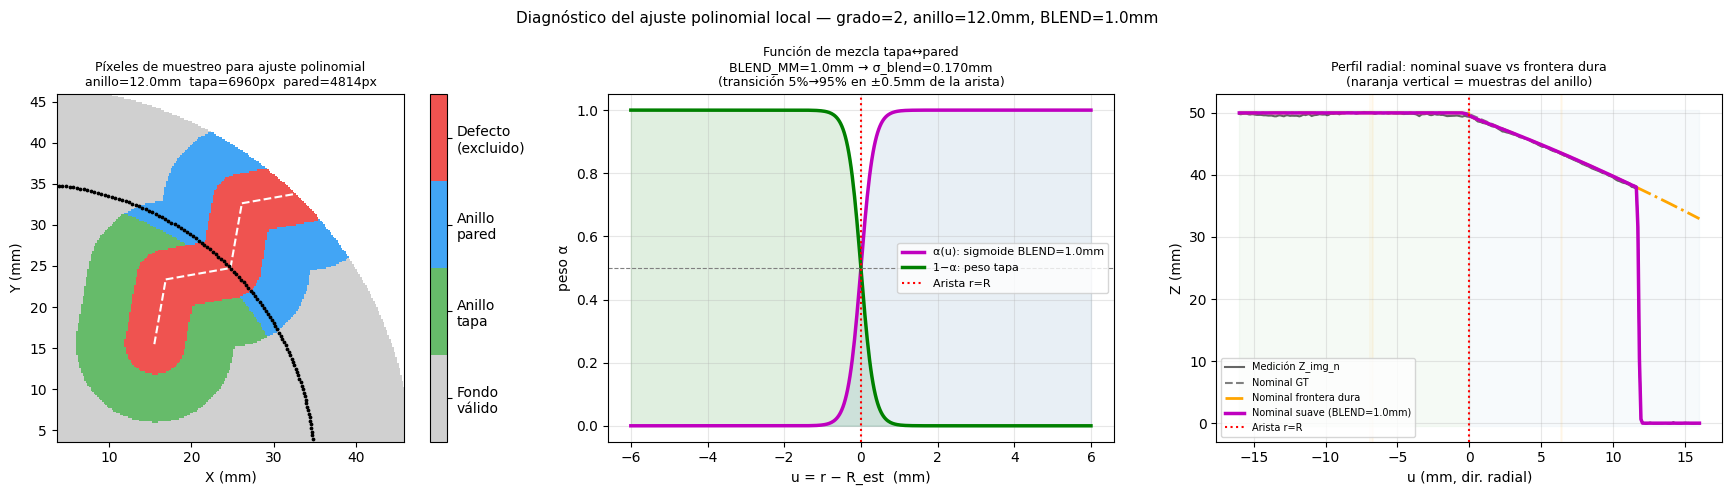

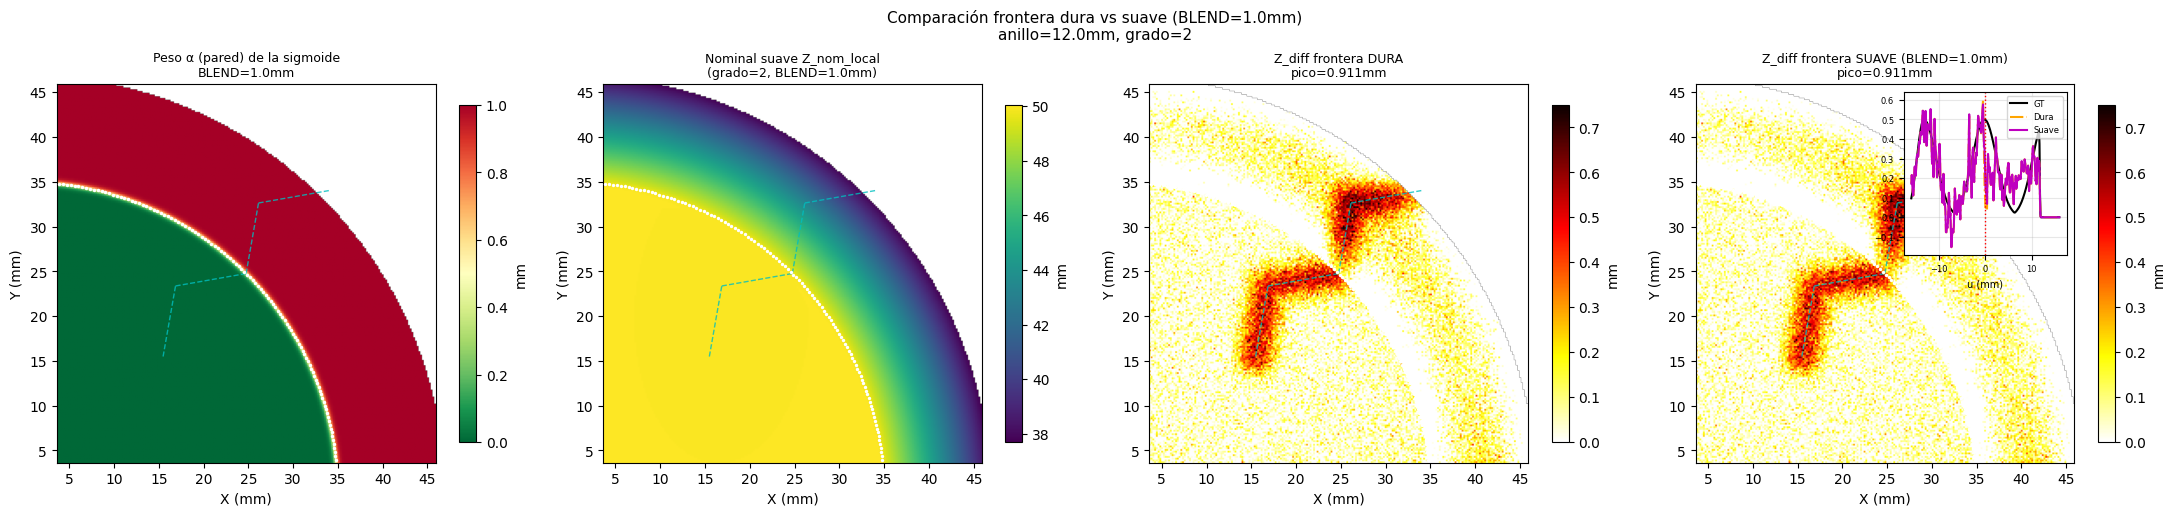

In [9]:

from scipy.ndimage import map_coordinates

# ── Perfil radial de referencia ───────────────────────────────────────────────
n_pts = 300
u_line = np.linspace(-16, 16, n_pts)
x_prf  = crack_center[0] + u_line * CRACK_DIR[0]
y_prf  = crack_center[1] + u_line * CRACK_DIR[1]
xi_prf = (x_prf - x_vec[0]) / dx
yi_prf = (y_prf - y_vec[0]) / dy
vmsk   = (xi_prf >= 0) & (xi_prf < N_COLS) & (yi_prf >= 0) & (yi_prf < N_ROWS)
u_v    = u_line[vmsk]

ring_rl_prof = map_coordinates((ring_tapa_rl | ring_pared_rl).astype(float),
                               [yi_prf, xi_prf], order=0, prefilter=False) > 0.5
meas_p   = map_coordinates(Z_img_n,       [yi_prf, xi_prf], order=1, prefilter=False)
nom_t_p  = map_coordinates(Z_nom_tapa_rl, [yi_prf, xi_prf], order=1, prefilter=False)
nom_p_p  = map_coordinates(Z_nom_pared_rl,[yi_prf, xi_prf], order=1, prefilter=False)
nom_l_p  = map_coordinates(Z_nom_local,   [yi_prf, xi_prf], order=1, prefilter=False)
gt_nom_p = map_coordinates(Z_nominal,     [yi_prf, xi_prf], order=1, prefilter=False)
diff_l_p = map_coordinates(Z_diff_local,  [yi_prf, xi_prf], order=1, prefilter=False)
def_p    = map_coordinates(defect,        [yi_prf, xi_prf], order=1, prefilter=False)
alpha_p  = map_coordinates(alpha,         [yi_prf, xi_prf], order=1, prefilter=False)

# Recalcular nominal con frontera dura para comparar
alpha_hard = (u_line >= 0).astype(float)
nom_hard_p = (1 - alpha_hard) * nom_t_p + alpha_hard * nom_p_p

# ── Figura 1: píxeles de muestreo + peso de la sigmoide ──────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

region_vis = np.full((N_ROWS, N_COLS), np.nan)
region_vis[mask_valid]      = 0.0
region_vis[ring_tapa_rl]    = 1.0
region_vis[ring_pared_rl]   = 2.0
region_vis[mask_defect]     = 3.0

import matplotlib.colors as mcolors
cmap_reg = mcolors.ListedColormap(['#d0d0d0', '#66bb6a', '#42a5f5', '#ef5350'])
im0 = axes[0].imshow(region_vis[jy0:jy1, jx0:jx1], origin='lower', extent=ext,
                     cmap=cmap_reg, vmin=0, vmax=3, interpolation='nearest')
cb0 = plt.colorbar(im0, ax=axes[0], ticks=[0.375, 1.125, 1.875, 2.625])
cb0.set_ticklabels(['Fondo\nválido', 'Anillo\ntapa', 'Anillo\npared', 'Defecto\n(excluido)'])
th_c = np.linspace(0, 2*np.pi, 500)
xc_v, yc_v = R*np.cos(th_c), R*np.sin(th_c)
in_roi = ((xc_v >= x_vec[jx0]) & (xc_v <= x_vec[jx1-1]) &
          (yc_v >= y_vec[jy0]) & (yc_v <= y_vec[jy1-1]))
axes[0].scatter(xc_v[in_roi], yc_v[in_roi], c='k', s=3, zorder=5)
for i in range(len(verts)-1):
    axes[0].plot([verts[i,0], verts[i+1,0]], [verts[i,1], verts[i+1,1]], 'w--', lw=1.5)
axes[0].set_title(f'Píxeles de muestreo para ajuste polinomial\n'
                  f'anillo={RING_LOCAL_MM}mm  tapa={ring_tapa_rl.sum()}px  pared={ring_pared_rl.sum()}px',
                  fontsize=9)
axes[0].set_xlabel('X (mm)'); axes[0].set_ylabel('Y (mm)')

# ── Figura 2: sigmoide de mezcla ─────────────────────────────────────────────
u_sig = np.linspace(-6, 6, 400)
blend_sigma_val = BLEND_MM / (2 * np.log(19)) if BLEND_MM > 0 else 1e-6
alpha_sig = 1.0 / (1.0 + np.exp(-u_sig / blend_sigma_val)) if BLEND_MM > 0 else (u_sig >= 0).astype(float)

ax2 = axes[1]
ax2.plot(u_sig, alpha_sig, 'm-', lw=2.5, label=f'α(u): sigmoide BLEND={BLEND_MM}mm')
ax2.plot(u_sig, 1 - alpha_sig, 'g-', lw=2.5, label='1−α: peso tapa')
ax2.axvline(0, color='red', lw=1.5, ls=':', label='Arista r=R')
ax2.axhline(0.5, color='gray', lw=0.8, ls='--')
ax2.fill_between(u_sig, 0, 1 - alpha_sig, alpha=0.12, color='green')
ax2.fill_between(u_sig, 0, alpha_sig,     alpha=0.12, color='steelblue')
ax2.set_xlabel('u = r − R_est  (mm)'); ax2.set_ylabel('peso α')
ax2.set_title(f'Función de mezcla tapa↔pared\n'
              f'BLEND_MM={BLEND_MM}mm → σ_blend={blend_sigma_val:.3f}mm\n'
              f'(transición 5%→95% en ±{BLEND_MM/2:.1f}mm de la arista)', fontsize=9)
ax2.set_ylim(-0.05, 1.05); ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

# ── Figura 3: nominal suave vs frontera dura + Z_diff ────────────────────────
ax3 = axes[2]
ax3.plot(u_v, meas_p[vmsk],    'k-',   lw=1.5, alpha=0.6, label='Medición Z_img_n')
ax3.plot(u_v, gt_nom_p[vmsk],  'gray', lw=1.5, ls='--',   label='Nominal GT')
ax3.plot(u_v, nom_hard_p[vmsk],'orange', lw=2, ls='-.',   label='Nominal frontera dura')
ax3.plot(u_v, nom_l_p[vmsk],   'm-',   lw=2.5,            label=f'Nominal suave (BLEND={BLEND_MM}mm)')
for uu, rr in zip(u_v, ring_rl_prof[vmsk]):
    if rr:
        ax3.axvline(uu, color='orange', lw=0.3, alpha=0.25, zorder=0)
ax3.axvline(0, color='red', lw=1.5, ls=':', label='Arista r=R')
ax3.fill_betweenx([meas_p[vmsk].min()-0.3, meas_p[vmsk].max()+0.3], -16, 0,
                   alpha=0.04, color='green')
ax3.fill_betweenx([meas_p[vmsk].min()-0.3, meas_p[vmsk].max()+0.3],  0, 16,
                   alpha=0.04, color='steelblue')
ax3.set_xlabel('u (mm, dir. radial)'); ax3.set_ylabel('Z (mm)')
ax3.set_title('Perfil radial: nominal suave vs frontera dura\n'
              '(naranja vertical = muestras del anillo)', fontsize=9)
ax3.legend(fontsize=7, loc='lower left'); ax3.grid(alpha=0.3)

plt.suptitle(f'Diagnóstico del ajuste polinomial local — grado={POLY_DEG}, anillo={RING_LOCAL_MM}mm, BLEND={BLEND_MM}mm',
             fontsize=11)
plt.tight_layout()
plt.show()

# ── Figura 2: Z_diff frontera dura vs suave (perfil + mapa) ──────────────────
# Calcular Z_diff con frontera dura para comparar
Z_nom_hard  = np.where(mask_valid, (r_img < R_est_fit_n)*Z_nom_tapa_rl + (r_img >= R_est_fit_n)*Z_nom_pared_rl, 0.0)
Z_diff_hard = np.where(mask_valid, Z_nom_hard - Z_img_n, 0.0)
diff_h_p = map_coordinates(Z_diff_hard, [yi_prf, xi_prf], order=1, prefilter=False)

fig2, axes2 = plt.subplots(1, 4, figsize=(22, 5))

def ishow(ax, data, title, cmap, vmin=None, vmax=None):
    im = ax.imshow(data[jy0:jy1, jx0:jx1], origin='lower', extent=ext,
                   cmap=cmap, vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax, label='mm', shrink=0.8)
    ax.scatter(xc_v[in_roi], yc_v[in_roi], c='w', s=2, zorder=5)
    for i in range(len(verts)-1):
        ax.plot([verts[i,0], verts[i+1,0]], [verts[i,1], verts[i+1,1]], 'c--', lw=1, alpha=0.8)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('X (mm)'); ax.set_ylabel('Y (mm)')

ishow(axes2[0], np.where(mask_valid, alpha, np.nan),
      f'Peso α (pared) de la sigmoide\nBLEND={BLEND_MM}mm', 'RdYlGn_r', vmin=0, vmax=1)
ishow(axes2[1], np.where(mask_valid, Z_nom_local, np.nan),
      f'Nominal suave Z_nom_local\n(grado={POLY_DEG}, BLEND={BLEND_MM}mm)', 'viridis')
ishow(axes2[2], np.where(mask_valid, Z_diff_hard, np.nan),
      f'Z_diff frontera DURA\npico={Z_diff_hard[mask_defect].max():.3f}mm',
      'hot_r', vmin=0, vmax=CRACK_DEPTH*1.5)
ishow(axes2[3], np.where(mask_valid, Z_diff_local, np.nan),
      f'Z_diff frontera SUAVE (BLEND={BLEND_MM}mm)\npico={Z_diff_local[mask_defect].max():.3f}mm',
      'hot_r', vmin=0, vmax=CRACK_DEPTH*1.5)

# Perfil Z_diff dura vs suave
ax_ins = axes2[3].inset_axes([0.55, 0.55, 0.43, 0.43])
ax_ins.plot(u_v, def_p[vmsk],   'k-',      lw=1.5, label='GT')
ax_ins.plot(u_v, diff_h_p[vmsk],'orange',  lw=1.5, ls='-.', label='Dura')
ax_ins.plot(u_v, diff_l_p[vmsk],'m-',      lw=1.5, label=f'Suave')
ax_ins.axvline(0, color='red', lw=1, ls=':')
ax_ins.set_xlabel('u (mm)', fontsize=7); ax_ins.tick_params(labelsize=6)
ax_ins.legend(fontsize=6); ax_ins.grid(alpha=0.3)

plt.suptitle(f'Comparación frontera dura vs suave (BLEND={BLEND_MM}mm)\n'
             f'anillo={RING_LOCAL_MM}mm, grado={POLY_DEG}', fontsize=11)
plt.tight_layout()
plt.show()


## 7. Visualización de los tres Z_diff

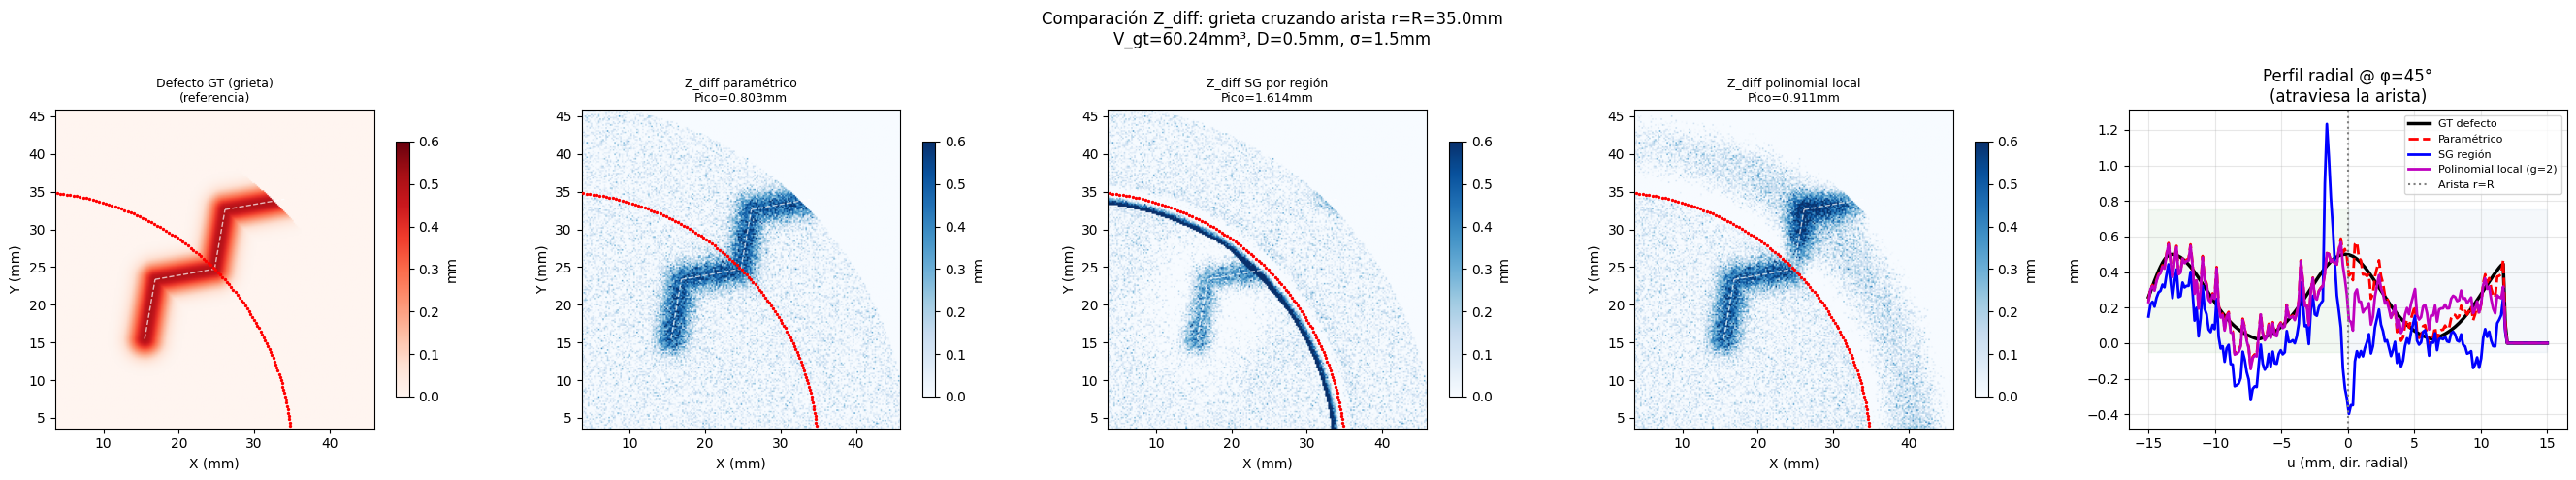

In [10]:
fig, axes = plt.subplots(1, 5, figsize=(27, 5))
vmax_d = CRACK_DEPTH * 1.2

th = np.linspace(0, 2*np.pi, 500)
xc_all, yc_all = R*np.cos(th), R*np.sin(th)
in_roi_arc = ((xc_all >= x_vec[jx0]) & (xc_all <= x_vec[jx1-1]) &
              (yc_all >= y_vec[jy0]) & (yc_all <= y_vec[jy1-1]))

def imr(ax, data, title, cmap='Blues'):
    im = ax.imshow(data[jy0:jy1, jx0:jx1], origin='lower', extent=ext,
                   cmap=cmap, vmin=0, vmax=vmax_d)
    plt.colorbar(im, ax=ax, label='mm', shrink=0.8)
    if in_roi_arc.any():
        ax.scatter(xc_all[in_roi_arc], yc_all[in_roi_arc], c='r', s=2, zorder=5)
    for i in range(len(verts)-1):
        ax.plot([verts[i,0], verts[i+1,0]], [verts[i,1], verts[i+1,1]], 'w--', lw=1, alpha=0.7)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('X (mm)'); ax.set_ylabel('Y (mm)')

imr(axes[0], defect, 'Defecto GT (grieta)\n(referencia)', cmap='Reds')
imr(axes[1], Z_diff_final,   f'Z_diff paramétrico\nPico={Z_diff_final[mask_defect].max():.3f}mm')
imr(axes[2], Z_diff_sg,      f'Z_diff SG por región\nPico={Z_diff_sg[mask_defect].max():.3f}mm')
imr(axes[3], Z_diff_local,   f'Z_diff polinomial local\nPico={Z_diff_local[mask_defect].max():.3f}mm')

# Perfil radial comparativo
from scipy.ndimage import map_coordinates
n_pts = 200
u_line = np.linspace(-15, 15, n_pts)
x_prof = crack_center[0] + u_line * CRACK_DIR[0]
y_prof = crack_center[1] + u_line * CRACK_DIR[1]
xi_p   = (x_prof - x_vec[0]) / dx
yi_p   = (y_prof - y_vec[0]) / dy
vd_msk = (xi_p >= 0) & (xi_p < N_COLS) & (yi_p >= 0) & (yi_p < N_ROWS)

gt_prof    = map_coordinates(defect,        [yi_p, xi_p], order=1, prefilter=False)
par_prof   = map_coordinates(Z_diff_final,  [yi_p, xi_p], order=1, prefilter=False)
sg_prof    = map_coordinates(Z_diff_sg,     [yi_p, xi_p], order=1, prefilter=False)
loc_prof   = map_coordinates(Z_diff_local,  [yi_p, xi_p], order=1, prefilter=False)

axes[4].plot(u_line[vd_msk], gt_prof[vd_msk],   'k-',  lw=2.5, label='GT defecto')
axes[4].plot(u_line[vd_msk], par_prof[vd_msk],  'r--', lw=2,   label='Paramétrico')
axes[4].plot(u_line[vd_msk], sg_prof[vd_msk],   'b-',  lw=2,   label='SG región')
axes[4].plot(u_line[vd_msk], loc_prof[vd_msk],  'm-',  lw=2,   label=f'Polinomial local (g={POLY_DEG})')
axes[4].axvline(0, color='gray', lw=1.5, ls=':', label='Arista r=R')
axes[4].fill_betweenx([-0.05, CRACK_DEPTH*1.5], -15, 0, alpha=0.05, color='green')
axes[4].fill_betweenx([-0.05, CRACK_DEPTH*1.5],  0, 15, alpha=0.05, color='steelblue')
axes[4].set_xlabel('u (mm, dir. radial)'); axes[4].set_ylabel('mm')
axes[4].set_title('Perfil radial @ φ=45°\n(atraviesa la arista)')
axes[4].legend(fontsize=8); axes[4].grid(alpha=0.3)

plt.suptitle(f'Comparación Z_diff: grieta cruzando arista r=R={R}mm\n'
             f'V_gt={V_gt:.2f}mm³, D={CRACK_DEPTH}mm, σ={CRACK_SIGMA}mm', fontsize=12)
plt.tight_layout()
plt.show()


## 8. Funciones Multi-Splat

In [11]:
def gauss2d_rotated(params, x, y):
    A_p, x0_p, y0_p, sx_p, sy_p, th_p = params
    c, s = np.cos(th_p), np.sin(th_p)
    u =  (x - x0_p) * c + (y - y0_p) * s
    v = -(x - x0_p) * s + (y - y0_p) * c
    return A_p * np.exp(-0.5 * (u**2 / sx_p**2 + v**2 / sy_p**2))

def gauss_mixture(params, x, y):
    K = len(params) // 6
    out = np.zeros(len(x))
    for k in range(K):
        out += gauss2d_rotated(params[6*k:6*k+6], x, y)
    return out

def gauss_mixture_and_jac(params, x, y):
    K = len(params) // 6
    N = len(x)
    out = np.zeros(N); J = np.zeros((N, 6*K))
    for k in range(K):
        A_p, x0_p, y0_p, sx_p, sy_p, th_p = params[6*k:6*k+6]
        c, s = np.cos(th_p), np.sin(th_p)
        dxv = x - x0_p; dyv = y - y0_p
        u =  dxv*c + dyv*s; v = -dxv*s + dyv*c
        eu2 = u**2/sx_p**2; ev2 = v**2/sy_p**2
        g = A_p * np.exp(-0.5*(eu2+ev2))
        out += g
        J[:, 6*k]   = g / A_p
        J[:, 6*k+1] = g * (u*c/sx_p**2 - v*s/sy_p**2)
        J[:, 6*k+2] = g * (u*s/sx_p**2 + v*c/sy_p**2)
        J[:, 6*k+3] = g * eu2 / sx_p
        J[:, 6*k+4] = g * ev2 / sy_p
        J[:, 6*k+5] = g * (u*v/sx_p**2 - u*v/sy_p**2)
    return out, J

def volume_mixture(params):
    K = len(params) // 6
    return sum(params[6*k] * 2*np.pi * params[6*k+3] * params[6*k+4] for k in range(K))

class _CachedFit:
    def __init__(self):
        self._p_last = None; self._r_last = None; self._j_last = None
    def update(self, p, x, y, z):
        p = np.asarray(p)
        if self._p_last is None or not np.array_equal(p, self._p_last):
            self._p_last = p.copy()
            fit_v, j_v = gauss_mixture_and_jac(p, x, y)
            self._r_last = fit_v - z; self._j_last = j_v
    def r(self): return self._r_last
    def j(self): return self._j_last

def _make_cached_fit(K_, x_, y_, z_):
    cf = _CachedFit()
    def fun(p): cf.update(p, x_, y_, z_); return cf.r()
    def jac(p): cf.update(p, x_, y_, z_); return cf.j()
    return fun, jac

print('Funciones Multi-Splat definidas.')

Funciones Multi-Splat definidas.


## 9. Multi-Splat: ajuste K=1..9

In [12]:
WIN_DEFECT_MM = 12.0
WIN_DEFECT_PX = int(round(WIN_DEFECT_MM / min(dx, dy))) | 1

def run_multisplat(Z_diff_source, label):
    rows_m_, cols_m_ = np.where(mask_defect)
    x_obs_ = x_vec[cols_m_].astype(np.float64)
    y_obs_ = y_vec[rows_m_].astype(np.float64)
    z_obs_ = Z_diff_source[rows_m_, cols_m_].astype(np.float64)

    N_obs_ = len(z_obs_)
    N_SUB_ = min(1500, N_obs_)
    rng_   = np.random.default_rng(7)
    idx_   = rng_.choice(N_obs_, N_SUB_, replace=False)
    x_s = x_obs_[idx_]; y_s = y_obs_[idx_]; z_s = z_obs_[idx_]

    A_max_ = max(float(Z_diff_source[mask_defect].max()) * 2.5, 0.1)
    blo = [0,       -FOV_X/2, -FOV_Y/2,  0.3,  0.3, -np.pi/2]
    bhi = [A_max_,   FOV_X/2,  FOV_Y/2, 60.0, 60.0,  np.pi/2]

    coeffs_d_px = sg2d_jacobian_projection_cv2(Z_diff_source, window_size=WIN_DEFECT_PX)
    coeffs_d_ph = coeffs_to_physical(coeffs_d_px, dx, dy)

    K_list_ = [1, 2, 3, 4, 5, 6, 7, 8, 9]
    res_all  = {}; p_cur = []
    print(f'\n── {label} ──')
    t0 = _time.perf_counter()

    for K in range(1, max(K_list_) + 1):
        prev_full = gauss_mixture(p_cur, x_obs_, y_obs_) if p_cur else np.zeros(N_obs_)
        res_prev  = z_obs_ - prev_full
        res_img_  = np.zeros_like(Z_diff_source)
        res_img_[rows_m_, cols_m_] = res_prev
        f_ws = np.where(mask_defect, res_img_, -np.inf)
        pr, pc = np.unravel_index(np.argmax(f_ws), f_ws.shape)
        mX_ws = float(x_vec[pc]); mY_ws = float(y_vec[pr])

        if K == 1:
            a0_, b0_, c0_, d0_, e0_, f0_ = coeffs_d_ph[pr, pc, :]
            Hm = np.array([[2*a0_, c0_], [c0_, 2*b0_]])
            try:
                dlt_ = -np.linalg.solve(Hm, [d0_, e0_])
                mX_ws = float(np.clip(x_vec[pc] + dlt_[0], blo[1]+1e-6, bhi[1]-1e-6))
                mY_ws = float(np.clip(y_vec[pr] + dlt_[1], blo[2]+1e-6, bhi[2]-1e-6))
                A_ws_ = float(np.clip(f0_, blo[0]+1e-6, bhi[0]-1e-6))
                Sm = -A_ws_ * np.linalg.inv(Hm) if A_ws_ > 1e-6 else None
                if Sm is not None:
                    ev__, evec__ = np.linalg.eigh(Sm)
                    ord__ = np.argsort(ev__)[::-1]
                    sx_ = min(float(np.sqrt(abs(ev__[ord__[0]]))), WIN_DEFECT_MM*0.5)
                    sy_ = min(float(np.sqrt(abs(ev__[ord__[1]]))), WIN_DEFECT_MM*0.5)
                    th_ = float(np.arctan2(evec__[1, ord__[0]], evec__[0, ord__[0]]))
                else:
                    sx_, sy_, th_ = SEG_L*0.5, CRACK_SIGMA, 0.0
            except Exception:
                A_ws_ = float(np.clip(Z_diff_source[pr, pc], blo[0]+1e-6, bhi[0]-1e-6))
                sx_, sy_, th_ = SEG_L*0.5, CRACK_SIGMA, 0.0
        else:
            A_ws_ = float(np.clip(Z_diff_source[pr, pc], blo[0]+1e-6, bhi[0]-1e-6))
            sx_, sy_, th_ = SEG_L*0.3, CRACK_SIGMA*0.8, 0.0

        p_new_ = [float(np.clip(A_ws_, blo[0]+1e-6, bhi[0]-1e-6)),
                  float(np.clip(mX_ws,  blo[1]+1e-6, bhi[1]-1e-6)),
                  float(np.clip(mY_ws,  blo[2]+1e-6, bhi[2]-1e-6)),
                  float(np.clip(sx_,    blo[3]+1e-6, bhi[3]-1e-6)),
                  float(np.clip(sy_,    blo[4]+1e-6, bhi[4]-1e-6)),
                  float(np.clip(th_,    blo[5]+1e-6, bhi[5]-1e-6))]
        p0_ = p_cur + p_new_
        fun_, jac_ = _make_cached_fit(K, x_s, y_s, z_s)
        rK = least_squares(fun_, p0_, jac=jac_,
                           bounds=(blo*K, bhi*K), method='trf',
                           xtol=1e-9, ftol=1e-9, gtol=1e-9, max_nfev=10_000)
        p_cur = list(rK.x)
        V_K_  = volume_mixture(p_cur)
        eV_   = 100 * (V_K_ - V_gt) / V_gt
        t_K_  = _time.perf_counter() - t0
        res_all[K] = dict(params=p_cur.copy(), V=V_K_, err=eV_, nfev=rK.nfev, t=t_K_)
        print(f'  K={K}: V={V_K_:.2f} mm³  err={eV_:+.2f}%  nfev={rK.nfev}  t={t_K_*1000:.0f}ms')

    K_best_ = min(res_all, key=lambda k: abs(res_all[k]['err']))
    print(f'  K_best={K_best_}  err={res_all[K_best_]["err"]:+.2f}%')
    return res_all, K_best_

results_par,     K_best_par     = run_multisplat(Z_diff_final,   'Paramétrico')
results_clipped, K_best_clipped = run_multisplat(Z_diff_clipped, 'Paramétrico clipado [0,∞]')
results_sg,      K_best_sg      = run_multisplat(Z_diff_sg,      f'SG por región (W_tapa={WIN_NOM_TAPA_MM:.0f}mm, W_pared={WIN_NOM_PARED_MM:.0f}mm)')
results_local,   K_best_local   = run_multisplat(Z_diff_local,   f'Polinomial local (anillo={RING_LOCAL_MM:.0f}mm, grado={POLY_DEG})')



── Paramétrico ──
  K=1: V=344.98 mm³  err=+472.66%  nfev=19  t=6ms
  K=2: V=156.68 mm³  err=+160.08%  nfev=20  t=12ms
  K=3: V=101.57 mm³  err=+68.60%  nfev=17  t=24ms
  K=4: V=90.84 mm³  err=+50.79%  nfev=24  t=39ms
  K=5: V=70.69 mm³  err=+17.35%  nfev=18  t=51ms
  K=6: V=75.27 mm³  err=+24.95%  nfev=18  t=63ms
  K=7: V=70.12 mm³  err=+16.39%  nfev=18  t=464ms
  K=8: V=68.55 mm³  err=+13.79%  nfev=20  t=609ms
  K=9: V=67.93 mm³  err=+12.77%  nfev=21  t=709ms
  K_best=9  err=+12.77%

── Paramétrico clipado [0,∞] ──
  K=1: V=380.89 mm³  err=+532.28%  nfev=19  t=4ms
  K=2: V=154.36 mm³  err=+156.23%  nfev=20  t=12ms
  K=3: V=105.20 mm³  err=+74.63%  nfev=18  t=23ms
  K=4: V=79.88 mm³  err=+32.60%  nfev=18  t=39ms
  K=5: V=78.98 mm³  err=+31.10%  nfev=19  t=68ms
  K=6: V=76.22 mm³  err=+26.52%  nfev=17  t=97ms
  K=7: V=77.52 mm³  err=+28.68%  nfev=24  t=174ms
  K=8: V=70.64 mm³  err=+17.25%  nfev=21  t=228ms
  K=9: V=67.34 mm³  err=+11.78%  nfev=21  t=304ms
  K_best=9  err=+11.78%

── 

## 10. Resultados y comparativa

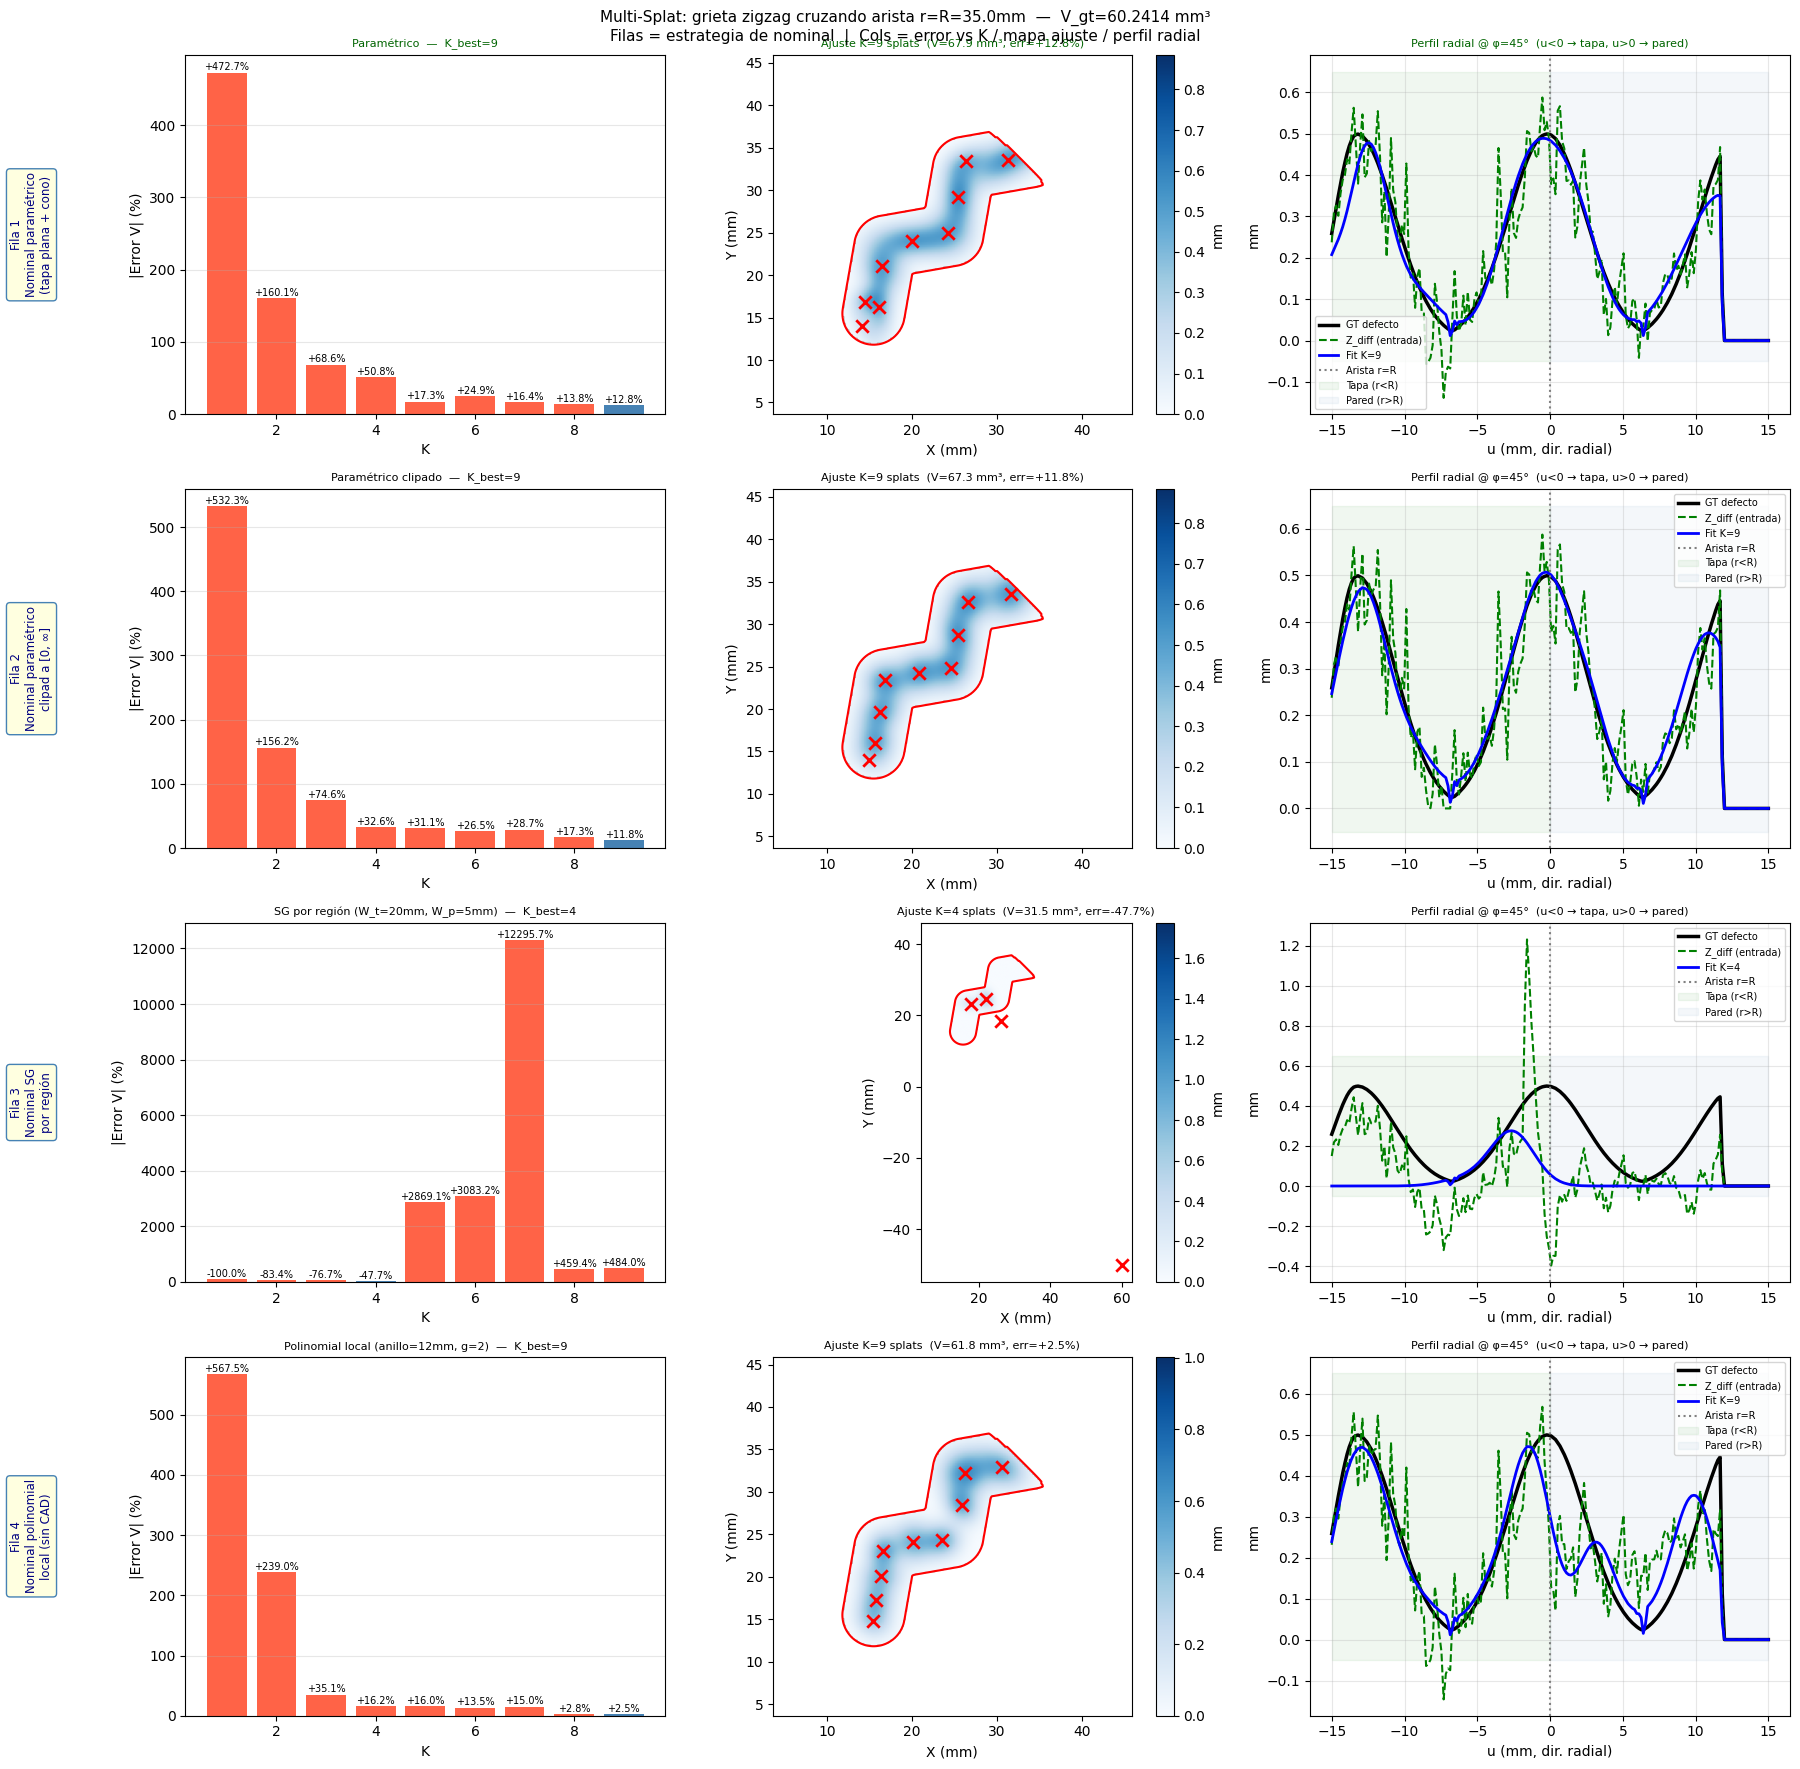


V_gt = 60.2414 mm³

  K       Param       err        Clip       err      SG-reg       err   PolyLocal       err
───────────────────────────────────────────────────────────────────────────────────────────
  1      344.98  +472.66%        380.89  +532.28%          0.00  -100.00%        402.10  +567.48%  
  2      156.68  +160.08%        154.36  +156.23%         10.00   -83.40%        204.25  +239.05%  
  3      101.57   +68.60%        105.20   +74.63%         14.03   -76.72%         81.41   +35.14%  
  4       90.84   +50.79%         79.88   +32.60%         31.54   -47.65% ◄       70.02   +16.23%  
  5       70.69   +17.35%         78.98   +31.10%       1788.61  +2869.07%         69.91   +16.05%  
  6       75.27   +24.95%         76.22   +26.52%       1917.61  +3083.21%         68.35   +13.46%  
  7       70.12   +16.39%         77.52   +28.68%       7467.33  +12295.68%         69.26   +14.97%  
  8       68.55   +13.79%         70.64   +17.25%        336.99  +459.40%         61.95    

In [13]:
fig, axes = plt.subplots(4, 3, figsize=(18, 18))

# Etiquetas de fila en el margen izquierdo
row_labels = [
    'Fila 1\nNominal paramétrico\n(tapa plana + cono)',
    'Fila 2\nNominal paramétrico\nclipad a [0, ∞]',
    'Fila 3\nNominal SG\npor región',
    'Fila 4\nNominal polinomial\nlocal (sin CAD)',
]
for row, lbl in enumerate(row_labels):
    axes[row, 0].annotate(
        lbl, xy=(-0.32, 0.5), xycoords='axes fraction',
        fontsize=8.5, ha='center', va='center',
        rotation=90, color='navy',
        bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', ec='steelblue', lw=1),
    )

# Etiquetas de columna en la parte superior
col_labels = [
    'Col 1: |error en volumen| vs K\n(azul = K_best)',
    'Col 2: ajuste Multi-Splat (K_best)\n(contorno rojo = GT, × = centros)',
    'Col 3: perfil radial @ φ=45°\n(atraviesa la arista)',
]
for col, lbl in enumerate(col_labels):
    axes[0, col].set_title(lbl + '\n', fontsize=8, color='darkgreen', pad=10)

def plot_row(res_dict, K_b, Z_diff_src, label, row):
    K_done = sorted(res_dict.keys())
    ev_ = [res_dict[k]['err'] for k in K_done]
    colors = ['tomato' if k != K_b else 'steelblue' for k in K_done]
    axes[row, 0].bar(K_done, [abs(e) for e in ev_], color=colors)
    for k, e in zip(K_done, ev_):
        axes[row, 0].text(k, abs(e) + 0.5, f'{e:+.1f}%',
                          ha='center', va='bottom', fontsize=7)
    axes[row, 0].set_xlabel('K'); axes[row, 0].set_ylabel('|Error V| (%)')
    axes[row, 0].set_title(f'{label}  —  K_best={K_b}', fontsize=8)
    axes[row, 0].grid(alpha=0.3, axis='y')

    p_b = np.array(res_dict[K_b]['params'])
    rows_m_, cols_m_ = np.where(mask_defect)
    x_o = x_vec[cols_m_].astype(float); y_o = y_vec[rows_m_].astype(float)
    fit_b = gauss_mixture(p_b, x_o, y_o)
    fit_img_ = np.zeros_like(Z_diff_src)
    fit_img_[rows_m_, cols_m_] = fit_b
    vmax_f_ = max(Z_diff_src[mask_defect].max(), 0.1) * 1.1
    im_ = axes[row, 1].imshow(np.where(mask_defect, fit_img_, np.nan)[jy0:jy1, jx0:jx1],
                               origin='lower', extent=ext, cmap='Blues', vmin=0, vmax=vmax_f_)
    plt.colorbar(im_, ax=axes[row, 1], label='mm')
    axes[row, 1].contour(defect[jy0:jy1, jx0:jx1], extent=ext,
                          levels=[CRACK_DEPTH * SEG_THRESHOLD], colors='r', linewidths=1.5)
    for k in range(K_b):
        axes[row, 1].scatter(p_b[6*k+1], p_b[6*k+2], s=80, marker='x',
                              color='red', lw=2, zorder=10)
    axes[row, 1].set_title(f'Ajuste K={K_b} splats  (V={res_dict[K_b]["V"]:.1f} mm³, err={res_dict[K_b]["err"]:+.1f}%)', fontsize=8)
    axes[row, 1].set_xlabel('X (mm)'); axes[row, 1].set_ylabel('Y (mm)')

    from scipy.ndimage import map_coordinates
    n_pts = 200
    u_line = np.linspace(-15, 15, n_pts)
    x_prof = crack_center[0] + u_line * CRACK_DIR[0]
    y_prof = crack_center[1] + u_line * CRACK_DIR[1]
    xi_p = (x_prof - x_vec[0]) / dx
    yi_p = (y_prof - y_vec[0]) / dy
    vmask = (xi_p >= 0) & (xi_p < N_COLS) & (yi_p >= 0) & (yi_p < N_ROWS)
    gt_p   = map_coordinates(defect,       [yi_p, xi_p], order=1, prefilter=False)
    src_p  = map_coordinates(Z_diff_src,   [yi_p, xi_p], order=1, prefilter=False)
    fit_p  = map_coordinates(fit_img_,     [yi_p, xi_p], order=1, prefilter=False)
    axes[row, 2].plot(u_line[vmask], gt_p[vmask],  'k-',  lw=2.5, label='GT defecto')
    axes[row, 2].plot(u_line[vmask], src_p[vmask], 'g--', lw=1.5, label='Z_diff (entrada)')
    axes[row, 2].plot(u_line[vmask], fit_p[vmask], 'b-',  lw=2,   label=f'Fit K={K_b}')
    axes[row, 2].axvline(0, color='gray', lw=1.5, ls=':', label='Arista r=R')
    axes[row, 2].fill_betweenx([-0.05, CRACK_DEPTH*1.3], -15, 0,
                                alpha=0.06, color='green', label='Tapa (r<R)')
    axes[row, 2].fill_betweenx([-0.05, CRACK_DEPTH*1.3],  0, 15,
                                alpha=0.06, color='steelblue', label='Pared (r>R)')
    axes[row, 2].set_xlabel('u (mm, dir. radial)'); axes[row, 2].set_ylabel('mm')
    axes[row, 2].set_title('Perfil radial @ φ=45°  (u<0 → tapa, u>0 → pared)', fontsize=8)
    axes[row, 2].legend(fontsize=7); axes[row, 2].grid(alpha=0.3)

plot_row(results_par,     K_best_par,     Z_diff_final,   'Paramétrico', 0)
plot_row(results_clipped, K_best_clipped, Z_diff_clipped, 'Paramétrico clipado', 1)
plot_row(results_sg,      K_best_sg,      Z_diff_sg,      f'SG por región (W_t={WIN_NOM_TAPA_MM:.0f}mm, W_p={WIN_NOM_PARED_MM:.0f}mm)', 2)
plot_row(results_local,   K_best_local,   Z_diff_local,   f'Polinomial local (anillo={RING_LOCAL_MM:.0f}mm, g={POLY_DEG})', 3)

plt.suptitle(f'Multi-Splat: grieta zigzag cruzando arista r=R={R}mm  —  V_gt={V_gt:.4f} mm³\n'
             f'Filas = estrategia de nominal  |  Cols = error vs K / mapa ajuste / perfil radial',
             fontsize=11)
plt.tight_layout()
plt.subplots_adjust(left=0.10)
plt.show()

# ── Tabla ─────────────────────────────────────────────────────────────────────
print(f'\nV_gt = {V_gt:.4f} mm³\n')
header = (f'{"K":>3}  {"Param":>10}  {"err":>8}  {"Clip":>10}  {"err":>8}  '
          f'{"SG-reg":>10}  {"err":>8}  {"PolyLocal":>10}  {"err":>8}')
print(header)
print('─' * len(header))
for k in sorted(results_par.keys()):
    rp = results_par[k]; rc = results_clipped[k]
    rs = results_sg[k];  rl = results_local[k]
    mp = ' ◄' if k == K_best_par     else '  '
    mc = ' ◄' if k == K_best_clipped else '  '
    ms = ' ◄' if k == K_best_sg      else '  '
    ml = ' ◄' if k == K_best_local   else '  '
    print(f'{k:>3}  {rp["V"]:>10.2f}  {rp["err"]:>+7.2f}%{mp}  '
          f'{rc["V"]:>10.2f}  {rc["err"]:>+7.2f}%{mc}  '
          f'{rs["V"]:>10.2f}  {rs["err"]:>+7.2f}%{ms}  '
          f'{rl["V"]:>10.2f}  {rl["err"]:>+7.2f}%{ml}')
